# Stage 1: Purchase Propensity Model

Binary classifier predicting **whether a customer will purchase in the 180-day holdout window**.

- **Target:** `purchased_in_holdout = (actual_holdout_transactions > 0)` — ~12.3% positive
- **Model:** XGBoost with `scale_pos_weight` for class imbalance + isotonic calibration
- **Primary metric:** PR-AUC (baseline = 0.123)

**Outputs:**
- `models/purchase_propensity_model.pkl`
- `data/processed/stage1_scored.csv`

---

> **TODO:**

- explain why I chose XGBoost model instead of other ML (e.g., random forest, lightGBM, etc.)
- explain why I chose primary metric as PR-AUC.
- elaborate how `scale_pos_weight` helps class imbalance + **isotonic calibration**
- explain logic for determining params in XGBoost classifier
---

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
# from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    average_precision_score, 
    roc_auc_score,
    precision_recall_curve
)
import xgboost as xgb
from xgboost import XGBClassifier

## 1. Load and Prepare Data

In [25]:
df = pd.read_csv("../data/raw/clv_data.csv")

# Target: binary purchase indicator
df['purchased_in_holdout'] = (df['actual_holdout_transactions'] > 0).astype(int)

positive_rate = df['purchased_in_holdout'].mean()
print(f"Loaded {len(df):,} customers")
print(f"Positive class (purchased in holdout): {df['purchased_in_holdout'].sum():,} ({positive_rate:.1%})")
print(f"Negative class (no holdout purchase):  {(df['purchased_in_holdout'] == 0).sum():,} ({1 - positive_rate:.1%})")

Loaded 52,507 customers
Positive class (purchased in holdout): 6,451 (12.3%)
Negative class (no holdout purchase):  46,056 (87.7%)


In [26]:
df['country'].value_counts()

country
China             17843
United States     11627
Brasil             7807
South Korea        2816
France             2524
United Kingdom     2425
Germany            2203
Spain              2089
Japan              1243
Australia          1152
Belgium             645
Poland              122
Colombia              7
Deutschland           3
Austria               1
Name: count, dtype: int64

## 2. Feature Engineering

In [27]:
# Derived features 
# what fraction of lifetime included repeat activity
df['recency_ratio'] = df['recency'] / df['T']
df['purchase_rate'] = df['frequency'] / df['T']
df['recency_tenure_ratio'] = df['days_since_last_order'] / df['customer_tenure_days']
df['cart_rate'] = df['cart_events'] / df['total_sessions']

NUMERIC_FEATURES = [
    # Purchase history (BG/NBD inputs)
    'frequency', 'recency', 'T', 'monetary_value',
    # Transaction context
    'total_orders', 'avg_order_value', 'days_since_last_order',
    # Demographics
    'customer_tenure_days', 'age',
    # Engagement
    'total_sessions', 'total_events', 'days_since_last_visit',
    'avg_events_per_session', 'cart_events', 'product_view_events',
    # Derived
    'recency_ratio', 'purchase_rate', 'recency_tenure_ratio', 'cart_rate'
]

CATEGORICAL_FEATURES = ['gender', 'traffic_source', 'country']
FEATURE_COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', NUMERIC_FEATURES),
        ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATURES)
    ]
)

X = df[FEATURE_COLS]
y = df['purchased_in_holdout']

print(f"Features: {len(FEATURE_COLS)}")
print(f"Target distribution: {y.value_counts().to_dict()}")

Features: 22
Target distribution: {0: 46056, 1: 6451}


## 3. Train / Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} ({y_train.mean():.1%} positive)")
print(f"Test:  {len(X_test):,} ({y_test.mean():.1%} positive)")

Train: 42,005 (12.3% positive)
Test:  10,502 (12.3% positive)


## 4. Train XGBoost Classifier

In [29]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

clf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='aucpr',
        random_state=42,
        verbosity=0,
    ))
])

clf.fit(X_train, y_train)
clf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## 5. Probability Calibration

`scale_pos_weight` distorts raw probabilities. Isotonic regression calibrates them to match the true positive rate.

**Note:**
- `scale_pos_weight` helps the model pay attention to rare positives by increasing the loss contribution of positive examples. This effectively makes the algorithm behave as if positives are more common than they actually are. As a result, the model optimizes a **weighted loss rather than the true data distribution**, which improves classification performance on imbalanced data but can produce **poorly calibrated (typically inflated) probability estimates**.
- If we only care about **ranking customers** (e.g., top 10% marketing targets), calibration isn't critical. However, if probabilities are used for revenue forecasting, expected conversion rates, or decision thresholds, calibration becomes important.

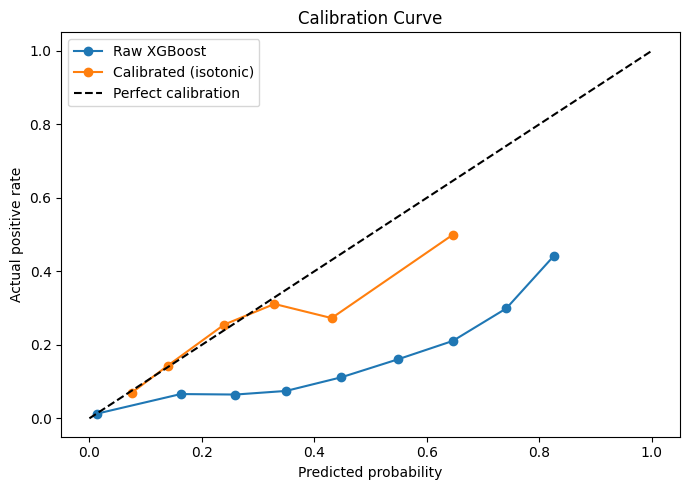

In [30]:
cal_clf = CalibratedClassifierCV(clf, method='isotonic', cv=5)  # isotonic regression learns monotonic function but doesn't assume a specific shape.
cal_clf.fit(X_train, y_train)

# Calibration curve on test set
y_prob_cal = cal_clf.predict_proba(X_test)[:, 1]
y_prob_raw = clf.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(7, 5))
for label, probs in [('Raw XGBoost', y_prob_raw), ('Calibrated (isotonic)', y_prob_cal)]:
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)
    ax.plot(prob_pred, prob_true, marker='o', label=label)
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Actual positive rate')
ax.set_title('Calibration Curve')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Evaluation

In [32]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss
)
from sklearn.model_selection import cross_val_score

y_prob = cal_clf.predict_proba(X_test)[:, 1]

pr = average_precision_score(y_test, y_prob)
roc = roc_auc_score(y_test, y_prob)
ll = log_loss(y_test, y_prob)

print(f"PR-AUC: {pr:.4f}")
print(f"ROC-AUC: {roc:.4f}")
print(f"LogLoss: {ll:.4f}")

scores = cross_val_score(cal_clf, X, y, cv=5, scoring="average_precision")
print(f"mean cross val score: {scores.mean():.4f}")
print(f"mean cross val std: {scores.std():.4f}")

PR-AUC: 0.2226
ROC-AUC: 0.6731
LogLoss: 0.3506
mean cross val score: 0.1834
mean cross val std: 0.0261


In [18]:
y_prob = cal_clf.predict_proba(X_test)[:, 1]

pr_auc  = average_precision_score(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
baseline = y_test.mean()

print("=== Purchase Propensity Model ===")
print(f"PR-AUC:   {pr_auc:.4f}  (baseline: {baseline:.4f}, lift: {pr_auc / baseline:.1f}x)")
print(f"ROC-AUC:  {roc_auc:.4f}")

=== Purchase Propensity Model ===
PR-AUC:   0.2212  (baseline: 0.1228, lift: 1.8x)
ROC-AUC:  0.6717


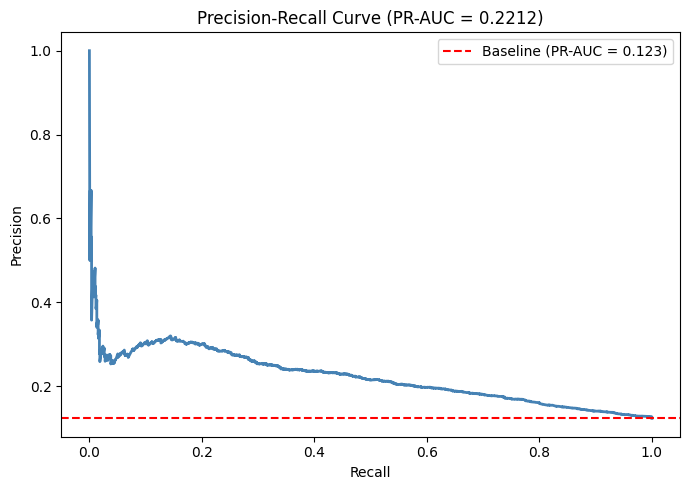

In [19]:
# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color='steelblue', linewidth=2)
ax.axhline(y=baseline, color='red', linestyle='--', label=f'Baseline (PR-AUC = {baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall Curve (PR-AUC = {pr_auc:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
# Decile analysis: bin customers by predicted probability, show actual purchase rate
test_df = pd.DataFrame({'y_true': y_test.values, 'y_prob': y_prob})
test_df['decile'] = pd.qcut(test_df['y_prob'], 10, labels=False, duplicates='drop') + 1

decile_stats = test_df.groupby('decile').agg(
    n_customers  = ('y_true', 'count'),
    actual_rate  = ('y_true', 'mean'),
    avg_prob     = ('y_prob', 'mean'),
).round(4)

print("=== Decile Analysis ===")
print(decile_stats.to_string())
print(f"\nTop decile purchase rate: {decile_stats.iloc[-1]['actual_rate']:.1%}")
print(f"Bottom decile purchase rate: {decile_stats.iloc[0]['actual_rate']:.1%}")
print(f"Lift (top vs bottom): {decile_stats.iloc[-1]['actual_rate'] / max(decile_stats.iloc[0]['actual_rate'], 0.001):.1f}x")

=== Decile Analysis ===
        n_customers  actual_rate  avg_prob
decile                                    
1              1053       0.0494    0.0432
2              1049       0.0620    0.0700
3              1053       0.0741    0.0787
4              1078       0.0742    0.0855
5              1019       0.0854    0.0941
6              1049       0.1115    0.1081
7              1058       0.1342    0.1290
8              1042       0.1660    0.1551
9              1053       0.1890    0.1964
10             1048       0.2834    0.2670

Top decile purchase rate: 28.3%
Bottom decile purchase rate: 4.9%
Lift (top vs bottom): 5.7x


## 7. Feature Importance

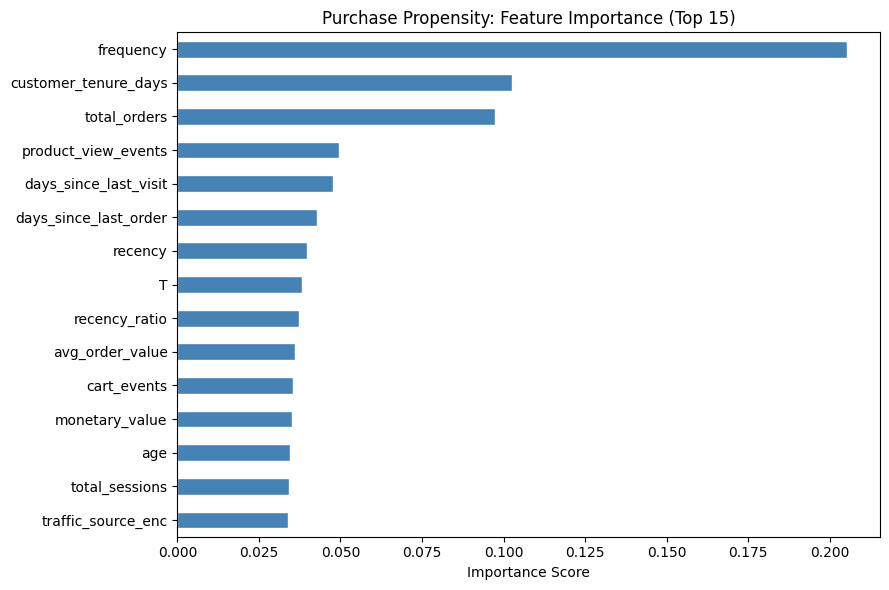

In [ ]:
importance = pd.Series(clf.feature_importances_, index=FEATURE_COLS)
top_features = importance.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
top_features.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Purchase Propensity: Feature Importance (Top 15)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 8. Score All Customers and Save

In [ ]:
# Score entire dataset
df['p_purchase'] = cal_clf.predict_proba(df[FEATURE_COLS])[:, 1]

print(f"p_purchase distribution:")
print(df['p_purchase'].describe().round(4))
print(f"\nMean p_purchase: {df['p_purchase'].mean():.4f} (base rate: {df['purchased_in_holdout'].mean():.4f})")

p_purchase distribution:
count    52507.0000
mean         0.1237
std          0.0683
min          0.0000
25%          0.0771
50%          0.1015
75%          0.1560
max          0.6542
Name: p_purchase, dtype: float64

Mean p_purchase: 0.1237 (base rate: 0.1229)


In [ ]:
# Save model and scored data
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

joblib.dump(cal_clf, '../models/purchase_propensity_model.pkl')
joblib.dump(label_encoders, '../models/label_encoders.pkl')
df.to_csv('../data/processed/stage1_scored.csv', index=False)

print(f"Model saved to models/purchase_propensity_model.pkl")
print(f"Label encoders saved to models/label_encoders.pkl")
print(f"Scored data saved to data/processed/stage1_scored.csv")
print(f"  Shape: {df.shape[0]:,} x {df.shape[1]}")

Model saved to models/purchase_propensity_model.pkl
Label encoders saved to models/label_encoders.pkl
Scored data saved to data/processed/stage1_scored.csv
  Shape: 52,507 x 30


In [ ]:
# Summary
print("=" * 50)
print("STAGE 1 SUMMARY: Purchase Propensity")
print("=" * 50)
print(f"Customers scored:  {len(df):,}")
print(f"PR-AUC:            {pr_auc:.4f} ({pr_auc / baseline:.1f}x lift over baseline)")
print(f"ROC-AUC:           {roc_auc:.4f}")
print(f"Mean p_purchase:   {df['p_purchase'].mean():.4f}")
print("=" * 50)
print("\nNext: 03_clv_regression.ipynb (Stage 2)")

STAGE 1 SUMMARY: Purchase Propensity
Customers scored:  52,507
PR-AUC:            0.2191 (1.8x lift over baseline)
ROC-AUC:           0.6736
Mean p_purchase:   0.1237

Next: 03_clv_regression.ipynb (Stage 2)
